# Steel Industry Energy Consumption
## Machine Learning Project – Phase 2: Visualization & Preprocessing

**Dataset:** [Steel Industry Energy Consumption – UCI ML Repository](https://archive-beta.ics.uci.edu/dataset/851/steel+industry+energy+consumption)

**Description:** Data collected from DAEWOO Steel Co. Ltd in Gwangyang, South Korea.  
It contains 35,040 records of energy consumption at 15-minute intervals.

---


## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load dataset via ucimlrepo (or CSV if already downloaded)
# from ucimlrepo import fetch_ucirepo
# dataset = fetch_ucirepo(id=851)
# df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
# df.insert(0, 'date', dataset.data.original['date'])

# ── Using local CSV (downloaded from UCI) ──
df = pd.read_csv('Steel_industry_data.csv', parse_dates=['date'])

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style='whitegrid')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (35040, 11)


## 2. Statistical Analysis
### 2.1 Preview – Top Rows

In [1]:
df.head()

                 date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM WeekStatus Day_of_week    Load_Type
0 2018-01-01 00:00:00     1.7974                                4.3029                                3.5306   0.001452                       97.8139                       80.4311     0    Weekday      Monday   Light_Load
1 2018-01-01 00:15:00     1.2954                                3.5825                                2.2621   0.000912                       95.5198                       90.0282   900    Weekday      Monday   Light_Load
2 2018-01-01 00:30:00     1.9421                                4.2012                                1.9332   0.001703                       93.1416                       78.2263  1800    Weekday      Monday   Light_Load
3 2018-01-01 00:45:00     2.6722                                6.1059                                0.4101   0

### 2.2 Shape & Data Types

In [1]:
print('Shape:', df.shape)
print()
print(df.dtypes)

Shape: (35040, 11)

date                                    datetime64[us]
Usage_kWh                                      float64
Lagging_Current_Reactive.Power_kVarh           float64
Leading_Current_Reactive_Power_kVarh           float64
CO2(tCO2)                                      float64
Lagging_Current_Power_Factor                   float64
Leading_Current_Power_Factor                   float64
NSM                                              int64
WeekStatus                                         str
Day_of_week                                        str
Load_Type                                          str


### 2.3 Descriptive Statistics (`describe`)

In [1]:
df.describe()

                      date     Usage_kWh  Lagging_Current_Reactive.Power_kVarh  Leading_Current_Reactive_Power_kVarh     CO2(tCO2)  Lagging_Current_Power_Factor  Leading_Current_Power_Factor           NSM
count                35040  35040.000000                          35040.000000                          35040.000000  35040.000000                  35040.000000                  35040.000000  35040.000000
mean   2018-07-02 11:52:30      3.862818                              9.660317                              1.485656      0.003091                     87.849569                     79.907464  42750.000000
min    2018-01-01 00:00:00      0.200000                              0.000000                              0.000000      0.000000                     66.902100                     50.000000      0.000000
25%    2018-04-02 05:56:15      2.128275                              5.332300                              0.422475      0.001706                     82.555200                    

### 2.4 Missing Values

In [1]:
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values per Column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0

Total missing values: 0


### 2.5 Unique Values in Categorical Columns

In [1]:
for col in ['WeekStatus', 'Day_of_week', 'Load_Type']:
    print(f"{col}: {df[col].unique().tolist()}")

WeekStatus: ['Weekday', 'Weekend']
Day_of_week: ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Load_Type: ['Light_Load', 'Medium_Load', 'Maximum_Load']


---
## 3. Visual Analysis

We will examine distribution, correlation, and temporal patterns across all features.


### 3.1 Distribution of Energy Consumption (`Usage_kWh`)

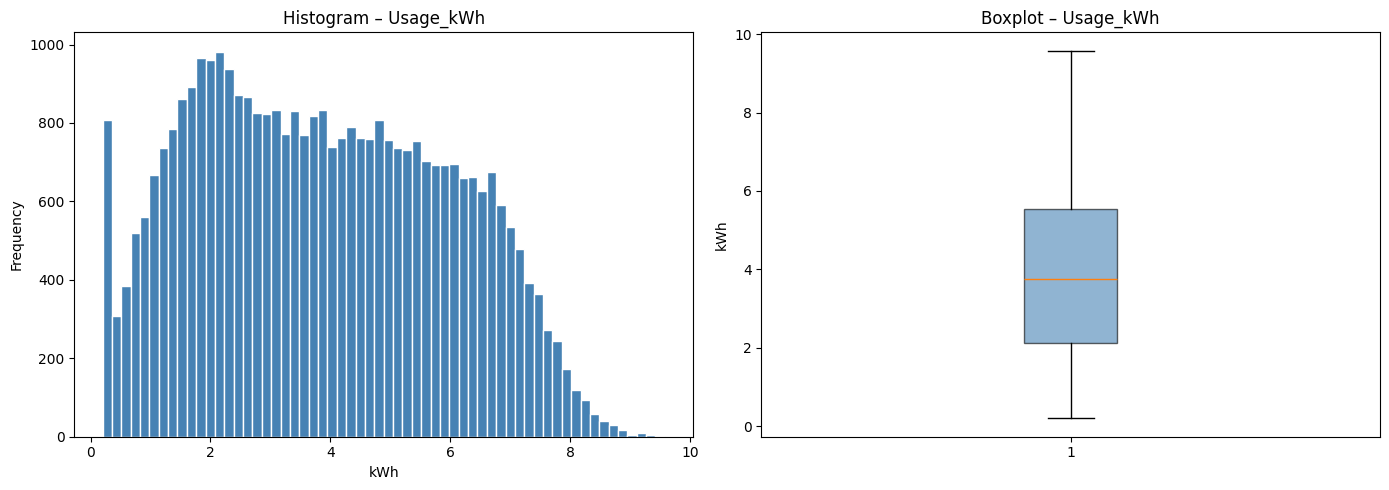

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Usage_kWh'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram – Usage_kWh')
axes[0].set_xlabel('kWh'); axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['Usage_kWh'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot – Usage_kWh')
axes[1].set_ylabel('kWh')
plt.tight_layout(); plt.show()

> **Observation:** `Usage_kWh` is right-skewed with most readings clustering between 0–5 kWh. The boxplot reveals several high-energy outliers that likely correspond to peak production hours.

### 3.2 Distribution of All Numeric Features

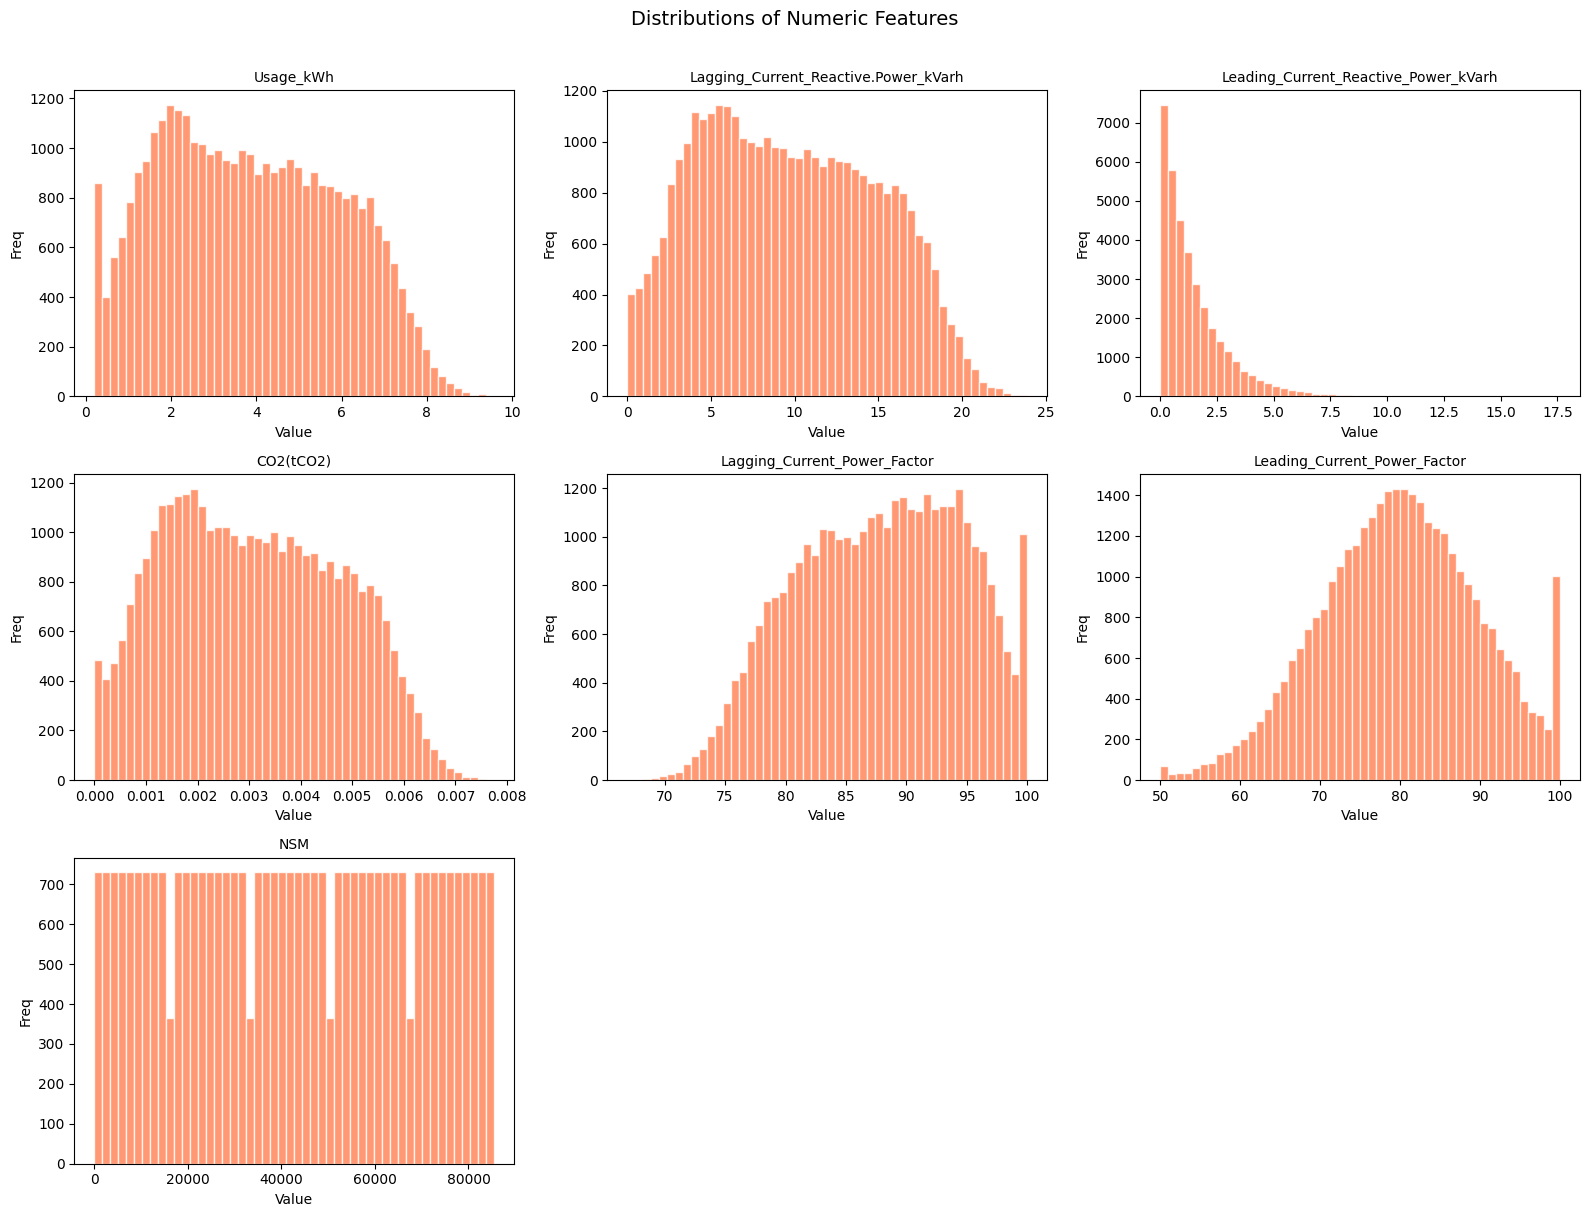

In [1]:
num_cols = ['Usage_kWh','Lagging_Current_Reactive.Power_kVarh',
            'Leading_Current_Reactive_Power_kVarh','CO2(tCO2)',
            'Lagging_Current_Power_Factor','Leading_Current_Power_Factor','NSM']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color='coral', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Freq')
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distributions of Numeric Features', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

> **Observation:** `NSM` (seconds from midnight) is nearly uniform — as expected since data is sampled every 15 min across all hours. `CO2` follows the same skewed pattern as energy. `Leading_Current_Reactive_Power_kVarh` is heavily zero-inflated.

### 3.3 Categorical Feature Distributions

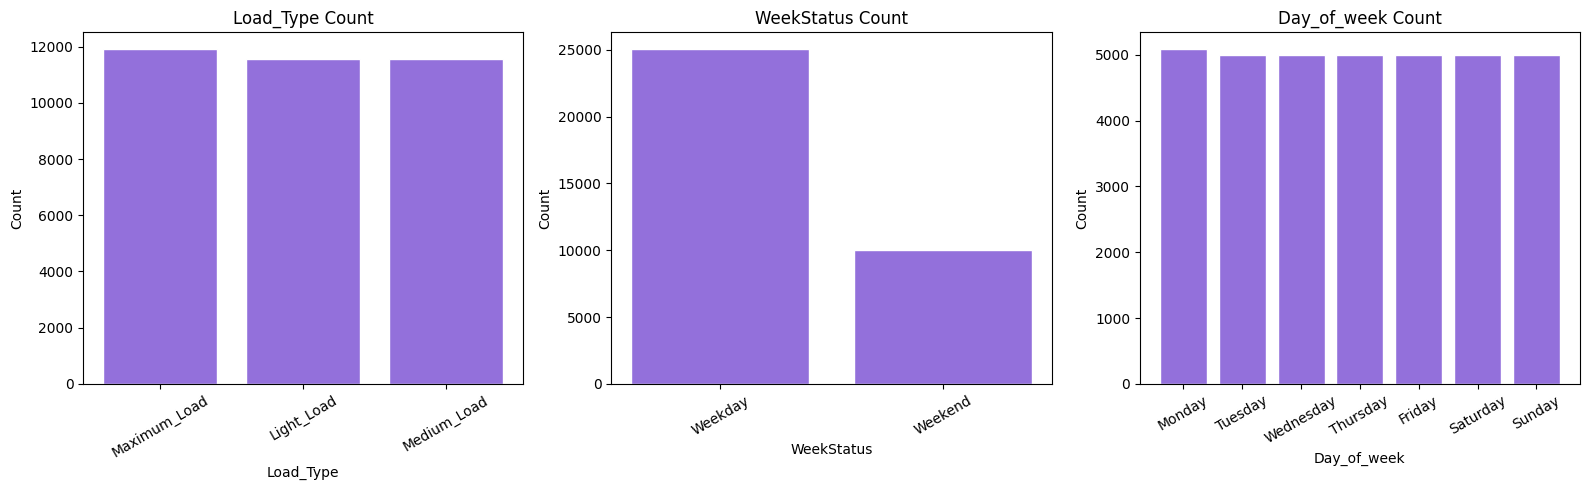

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Load_Type', 'WeekStatus', 'Day_of_week']):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='mediumpurple', edgecolor='white')
    ax.set_title(f'{col} Count')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

> **Observation:** The dataset is fairly balanced across load types. Weekdays dominate (~5/7 of the data). All 7 days are represented almost equally.

### 3.4 Energy Consumption by Load Type

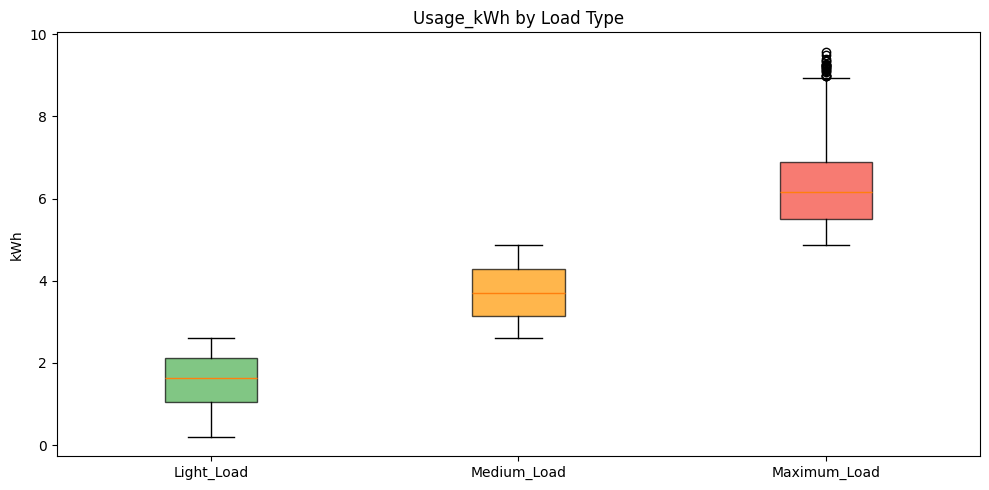

In [1]:
order = ['Light_Load', 'Medium_Load', 'Maximum_Load']
data_by_load = [df[df['Load_Type'] == lt]['Usage_kWh'].values for lt in order]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_load, labels=order, patch_artist=True,
                boxprops=dict(alpha=0.7))
colors = ['#4CAF50', '#FF9800', '#F44336']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Usage_kWh by Load Type'); ax.set_ylabel('kWh')
plt.tight_layout(); plt.show()

> **Observation:** Clear separation between load types — Maximum_Load has distinctly higher energy values, confirming this target variable is well-defined.

### 3.5 Energy Consumption: Weekday vs Weekend

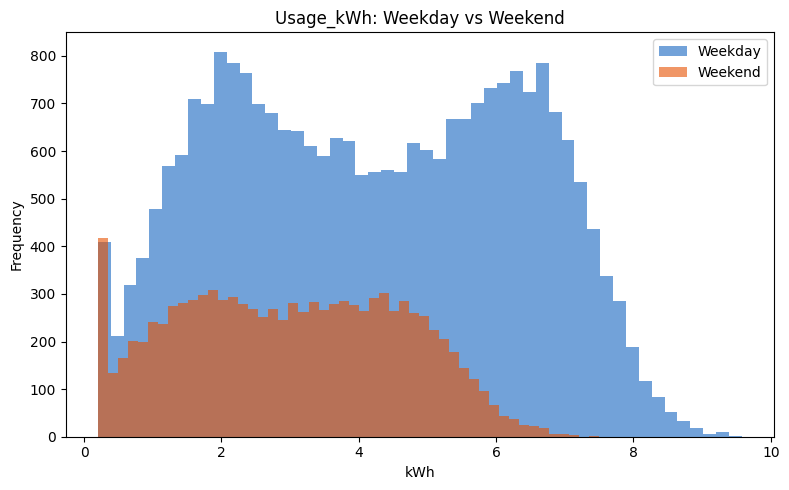

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
for ws, color in zip(['Weekday', 'Weekend'], ['#1565C0', '#E65100']):
    vals = df[df['WeekStatus'] == ws]['Usage_kWh']
    ax.hist(vals, bins=50, alpha=0.6, label=ws, color=color)
ax.set_title('Usage_kWh: Weekday vs Weekend')
ax.set_xlabel('kWh'); ax.set_ylabel('Frequency')
ax.legend(); plt.tight_layout(); plt.show()

> **Observation:** Weekdays show a broader, higher-energy distribution. Weekends tend to have lighter loads, indicating reduced industrial activity.

### 3.6 Average Energy Consumption by Hour of Day

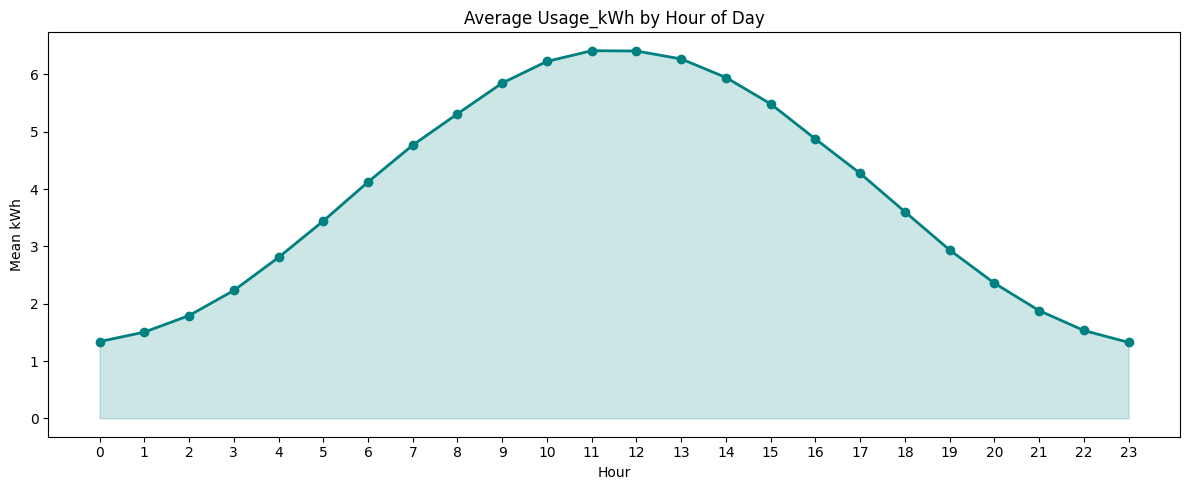

In [1]:
df['hour'] = pd.to_datetime(df['date']).dt.hour
hourly = df.groupby('hour')['Usage_kWh'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly.values, marker='o', color='teal', linewidth=2)
ax.fill_between(hourly.index, hourly.values, alpha=0.2, color='teal')
ax.set_title('Average Usage_kWh by Hour of Day')
ax.set_xlabel('Hour'); ax.set_ylabel('Mean kWh')
ax.set_xticks(range(0, 24))
plt.tight_layout(); plt.show()

> **Observation:** Energy peaks around 8–17 (working hours) and drops sharply at night. This temporal pattern is important for feature engineering.

### 3.7 Correlation Heatmap

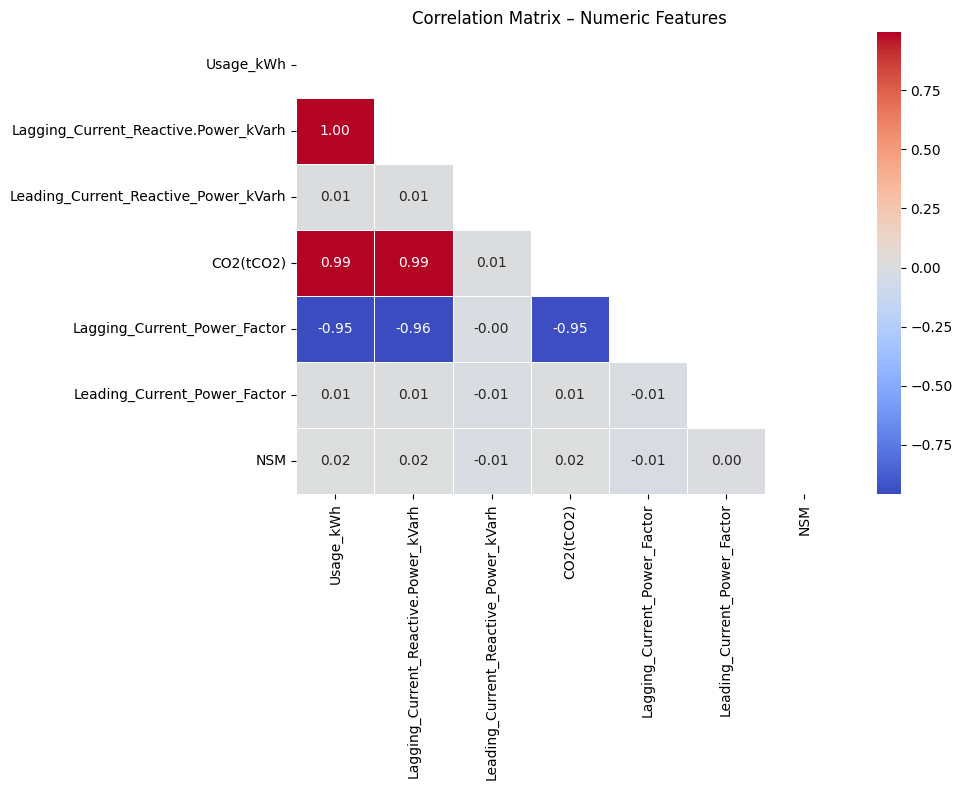

In [1]:
num_cols = ['Usage_kWh','Lagging_Current_Reactive.Power_kVarh',
            'Leading_Current_Reactive_Power_kVarh','CO2(tCO2)',
            'Lagging_Current_Power_Factor','Leading_Current_Power_Factor','NSM']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix – Numeric Features')
plt.tight_layout(); plt.show()

> **Observation:** `Usage_kWh` and `Lagging_Current_Reactive.Power_kVarh` show strong positive correlation. `CO2(tCO2)` is nearly perfectly correlated with `Usage_kWh` — suggesting it may be a **derived** feature.

### 3.8 Scatter Plot: Usage_kWh vs CO2

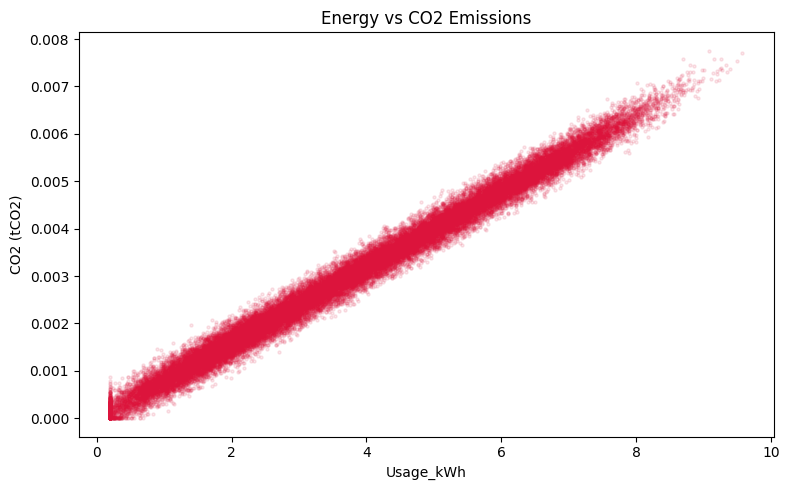

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Usage_kWh'], df['CO2(tCO2)'], alpha=0.1, s=5, color='crimson')
ax.set_xlabel('Usage_kWh'); ax.set_ylabel('CO2 (tCO2)')
ax.set_title('Energy vs CO2 Emissions')
plt.tight_layout(); plt.show()

> **Observation:** Almost perfect linear relationship between energy and CO2. This is expected since CO2 is directly derived from energy consumption. We will drop `CO2(tCO2)` during preprocessing to avoid data leakage.

### 3.9 Power Factor Features vs Energy Consumption

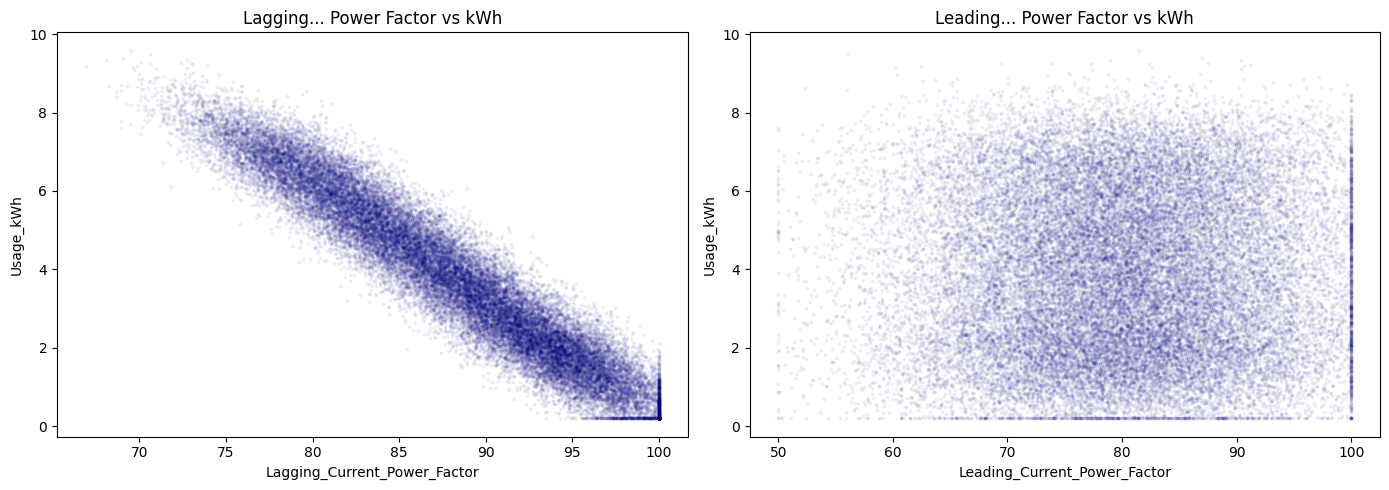

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pf in zip(axes, ['Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']):
    ax.scatter(df[pf], df['Usage_kWh'], alpha=0.05, s=3, color='navy')
    ax.set_xlabel(pf); ax.set_ylabel('Usage_kWh')
    ax.set_title(f'{pf} vs Usage_kWh')
plt.tight_layout(); plt.show()

### 3.10 Load Type Distribution by Day of Week

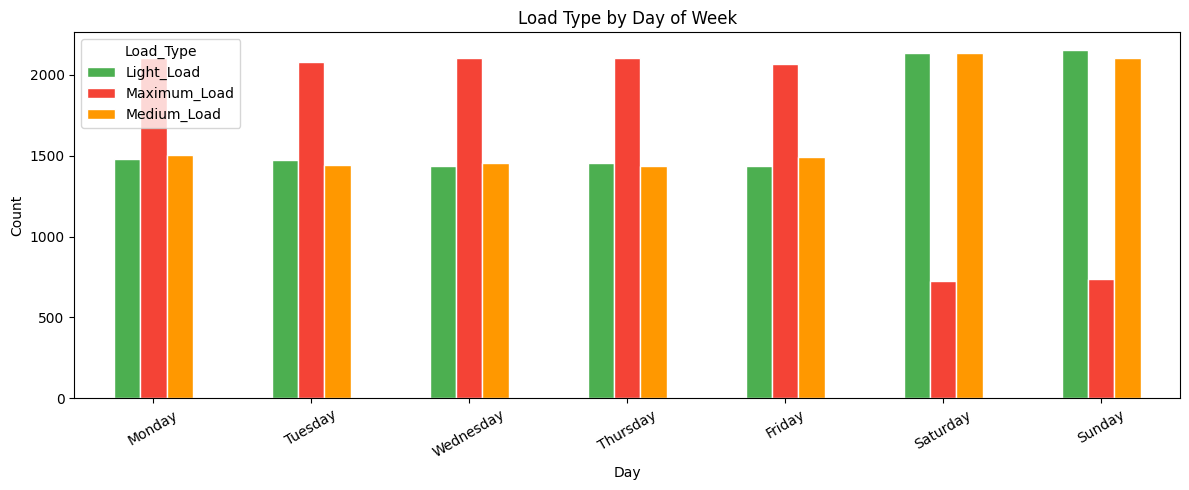

In [1]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ct = pd.crosstab(df['Day_of_week'], df['Load_Type']).reindex(dow_order)

fig, ax = plt.subplots(figsize=(12, 5))
ct.plot(kind='bar', ax=ax, color=['#4CAF50','#F44336','#FF9800'], edgecolor='white')
ax.set_title('Load Type by Day of Week')
ax.set_xlabel('Day'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

> **Observation:** Saturday and Sunday have almost exclusively Light_Load, confirming the factory runs at reduced capacity over weekends.

---
## 4. Preprocessing

Based on the visual analysis, we will now clean and transform the dataset step by step.
Each step includes a justification.


### 4.1 Extract Temporal Features from `date` Column

In [1]:
# The raw 'date' column is not directly usable by ML models.
# We extract meaningful temporal features: hour, day of month, and month.
# These numeric representations allow models to learn time-based patterns.

df['hour']  = pd.to_datetime(df['date']).dt.hour
df['day']   = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month

print("Extracted: hour, day, month from date column")
print(df[['date','hour','day','month']].head())

Extracted: hour, day, month from date column
                 date  hour  day  month
0 2018-01-01 00:00:00     0    1      1
1 2018-01-01 00:15:00     0    1      1
2 2018-01-01 00:30:00     0    1      1
3 2018-01-01 00:45:00     0    1      1
4 2018-01-01 01:00:00     1    1      1


### 4.2 Drop Irrelevant / Redundant Columns

In [1]:
# Drop 'date': Raw datetime is not a numeric feature; temporal info already extracted above.
# Drop 'CO2(tCO2)': Nearly perfectly correlated with Usage_kWh (corr ≈ 0.99).
#   Keeping it would cause data leakage and multicollinearity.

df.drop(columns=['date', 'CO2(tCO2)'], inplace=True)

print("Columns after dropping:", df.columns.tolist())
print("Shape:", df.shape)

Columns after dropping: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']
Shape: (35040, 9)


### 4.3 Encode Categorical Features

In [1]:
# Machine learning models require numeric inputs.
# WeekStatus is binary (Weekday/Weekend) → Label Encoding (0/1) is sufficient.
# Day_of_week has 7 unordered categories → We use pd.get_dummies (One-Hot Encoding)
#   to avoid implying an ordinal relationship between days.
# Load_Type is the target variable → Label Encoding is appropriate here.

# 1. WeekStatus
df['WeekStatus'] = df['WeekStatus'].map({'Weekday': 1, 'Weekend': 0})
print("WeekStatus mapped: Weekday=1, Weekend=0")

# 2. Day_of_week – One-Hot Encoding
df = pd.get_dummies(df, columns=['Day_of_week'], drop_first=True)
print("Day_of_week one-hot encoded (6 new columns, drop_first=True to avoid multicollinearity)")

# 3. Load_Type – Label Encoding
le = LabelEncoder()
df['Load_Type'] = le.fit_transform(df['Load_Type'])
print(f"Load_Type encoded: {dict(enumerate(le.classes_))}")

print("\nShape after encoding:", df.shape)
print(df.head())

WeekStatus mapped: Weekday=1, Weekend=0
Day_of_week one-hot encoded (6 new columns, drop_first=True to avoid multicollinearity)
Load_Type encoded: {0: 'Light_Load', 1: 'Maximum_Load', 2: 'Medium_Load'}

Shape after encoding: (35040, 17)


### 4.4 Outlier Detection and Handling

Usage_kWh: 0 outliers (IQR method)
Lagging_Current_Reactive.Power_kVarh: 0 outliers (IQR method)

Outlier clipping applied to all numeric columns.


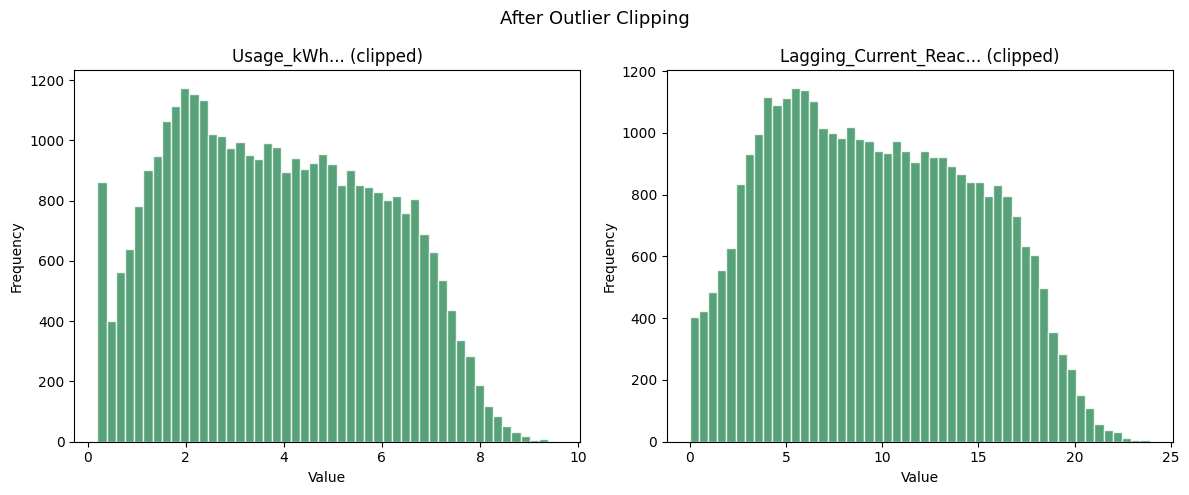

In [1]:
# Checking outliers with IQR method for key continuous features
for col in ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {n_out} outliers (IQR method)")

# We clip outliers instead of dropping rows to preserve the dataset size.
# Industrial energy data can have legitimate spikes (e.g., furnace ignition),
# so hard removal might lose real patterns. Clipping is a softer alternative.
scale_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
              'Leading_Current_Reactive_Power_kVarh',
              'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']

for col in scale_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("\nOutlier clipping applied to all numeric columns.")

### 4.5 Feature Scaling (StandardScaler)

In [1]:
# Most ML algorithms (SVM, KNN, Logistic Regression) are sensitive to feature scale.
# We standardize (zero mean, unit variance) all numeric feature columns.
# Note: 'Load_Type' is the target — we do NOT scale it.

from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df.columns if c != 'Load_Type']
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Features scaled using StandardScaler.")
print("\nScaled feature stats:")
print(df[feature_cols[:5]].describe().round(3))

Features scaled using StandardScaler.

Scaled feature stats:
       Usage_kWh  Lagging_Current_Reactive.Power_kVarh  Leading_Current_Reactive_Power_kVarh  Lagging_Current_Power_Factor  Leading_Current_Power_Factor
count  35040.000                             35040.000                             35040.000                        35040.000                        35040.000
mean       0.000                                 0.000                                 0.000                            0.000                            0.000
std        1.000                                 1.000                                 1.000                            1.000                            1.000
min       -2.413                                -2.102                                -1.502                           -2.971                           -3.144
25%       -0.849                                -0.816                                -0.728                           -0.690                         

### 4.6 Final Dataset Overview

In [1]:
print("Final DataFrame shape:", df.shape)
print("\nColumn list:")
for col in df.columns:
    print(f"  {col}")
print("\nTarget distribution (Load_Type):")
print(df['Load_Type'].value_counts())

Final DataFrame shape: (35040, 17)

Column list:
  Usage_kWh
  Lagging_Current_Reactive.Power_kVarh
  Leading_Current_Reactive_Power_kVarh
  Lagging_Current_Power_Factor
  Leading_Current_Power_Factor
  NSM
  WeekStatus
  Load_Type
  hour
  day
  month
  Day_of_week_Monday
  Day_of_week_Saturday
  Day_of_week_Sunday
  Day_of_week_Thursday
  Day_of_week_Tuesday
  Day_of_week_Wednesday

Target distribution (Load_Type):
0    11803
1    11680
2    11557
Name: Load_Type, dtype: int64


---
## 5. Save Preprocessed Dataset

We save the cleaned, encoded, and scaled dataset as a CSV for reuse in **Phase 3** (model building).
This avoids re-running all preprocessing in future notebooks.


In [1]:
df.to_csv('steel_preprocessed.csv', index=False)
print("Preprocessed dataset saved as: steel_preprocessed.csv")
print("Shape:", df.shape)
print("\nReady for Phase 3 – Model Building!")

Preprocessed dataset saved as: steel_preprocessed.csv
Shape: (35040, 17)

Ready for Phase 3 – Model Building!


---
## 6. Summary of Preprocessing Steps

| Step | Action | Reason |
|------|--------|--------|
| 1 | Extract `hour`, `day`, `month` from `date` | Raw datetime unusable by ML models |
| 2 | Drop `date` | Information captured in temporal features |
| 3 | Drop `CO2(tCO2)` | ~1.0 correlation with `Usage_kWh` → data leakage |
| 4 | Encode `WeekStatus` (0/1) | Binary categorical → simple map |
| 5 | One-Hot Encode `Day_of_week` | No ordinal relationship between days |
| 6 | Label Encode `Load_Type` | Target variable encoding |
| 7 | IQR Clipping on numeric cols | Remove extreme outliers without losing rows |
| 8 | StandardScaler on features | Normalize scale for ML algorithms |
